# W04

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astroML.datasets import fetch_dr7_quasar
from scipy.interpolate import interp1d
from astropy.cosmology import Planck18 as cosmo
from astropy import units as u

In [2]:
# Fetch the quasar data
data = fetch_dr7_quasar()

# select the first 10000 points
data = data[:10000]

z = data['redshift']

downloading DR7 quasar dataset from http://das.sdss.org/va/qsocat/dr7qso.dat.gz to /Users/lorenzaimpicicche/astroML_data
[=========================================]  12.82Mb / 12.82Mb   


(array([  2.,  24.,  85., 215., 291., 306., 354., 365., 372., 371., 493.,
        466., 565., 554., 500., 610., 552., 532., 503., 351., 367., 345.,
        266., 237., 201., 169., 143., 147., 107.,  80.,  75.,  58.,  56.,
         39.,  27.,  19.,  30.,  28.,  11.,  20.,  13.,  17.,   8.,   5.,
          5.,   2.,   1.,   5.,   1.,   2.,   4.,   0.,   0.,   0.,   1.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.]),
 array([ 0. ,  0.1,  0.2,  0.3,  0.4,  0.5,  0.6,  0.7,  0.8,  0.9,  1. ,
         1.1,  1.2,  1.3,  1.4,  1.5,  1.6,  1.7,  1.8,  1.9,  2. ,  2.1,
         2.2,  2.3,  2.4,  2.5,  2.6,  2.7,  2.8,  2.9,  3. ,  3.1,  3.2,
         3.3,  3.4,  3.5,  3.6,  3.7,  3.8,  3.9,  4. ,  4.1,  4.2,  4.3,
         4.4,  4.5,  4

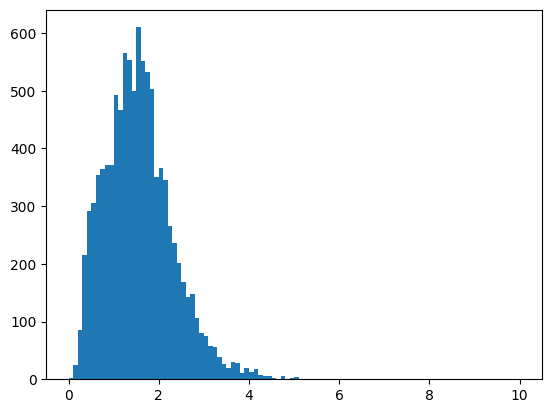

In [13]:
counts, edges =np.histogram(z,bins=np.linspace(0,10,101))
centers = 0.5 * (edges[:-1] + edges[1:])

plt.hist(z, bins=edges)

## Inverse Transform

(array([ 13.,  60., 147., 246., 305., 334., 379., 349., 383., 428., 492.,
        496., 573., 546., 544., 560., 548., 548., 434., 376., 357., 292.,
        226., 211., 186., 171., 137., 104.,  93.,  87.,  63.,  59.,  52.,
         34.,  23.,  24.,  21.,  20.,  12.,  20.,  14.,   9.,   4.,   3.,
          5.,   2.,   1.,   0.,   1.,   3.,   2.,   0.,   0.,   0.,   3.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.]),
 array([ 0. ,  0.1,  0.2,  0.3,  0.4,  0.5,  0.6,  0.7,  0.8,  0.9,  1. ,
         1.1,  1.2,  1.3,  1.4,  1.5,  1.6,  1.7,  1.8,  1.9,  2. ,  2.1,
         2.2,  2.3,  2.4,  2.5,  2.6,  2.7,  2.8,  2.9,  3. ,  3.1,  3.2,
         3.3,  3.4,  3.5,  3.6,  3.7,  3.8,  3.9,  4. ,  4.1,  4.2,  4.3,
         4.4,  4.5,  4

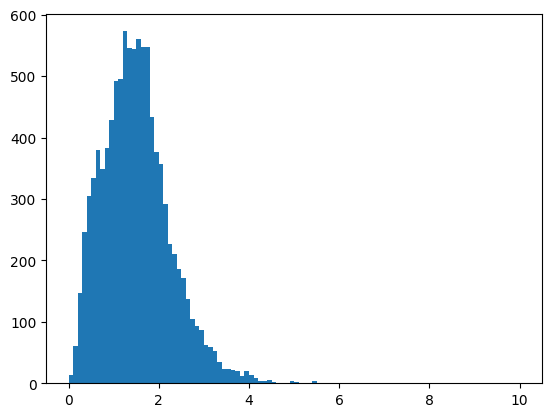

In [14]:
cdf = np.cumsum(counts)
cdf = cdf / cdf[-1]  # Normalizzo
inv_cdf = interp1d(cdf, centers, bounds_error=False, fill_value=(centers[0], centers[-1]))
z_inv = inv_cdf(np.random.rand(10000))

plt.hist(z_inv, bins=edges)

## Rejection Sampling

(array([  2.,  31.,  90., 193., 286., 317., 356., 368., 397., 408., 465.,
        475., 578., 583., 479., 592., 528., 526., 487., 363., 362., 349.,
        275., 240., 230., 164., 131., 140., 110.,  77.,  85.,  59.,  36.,
         31.,  23.,  20.,  24.,  26.,  12.,  16.,  16.,  15.,  13.,   6.,
          3.,   2.,   1.,   3.,   3.,   4.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.]),
 array([ 0. ,  0.1,  0.2,  0.3,  0.4,  0.5,  0.6,  0.7,  0.8,  0.9,  1. ,
         1.1,  1.2,  1.3,  1.4,  1.5,  1.6,  1.7,  1.8,  1.9,  2. ,  2.1,
         2.2,  2.3,  2.4,  2.5,  2.6,  2.7,  2.8,  2.9,  3. ,  3.1,  3.2,
         3.3,  3.4,  3.5,  3.6,  3.7,  3.8,  3.9,  4. ,  4.1,  4.2,  4.3,
         4.4,  4.5,  4

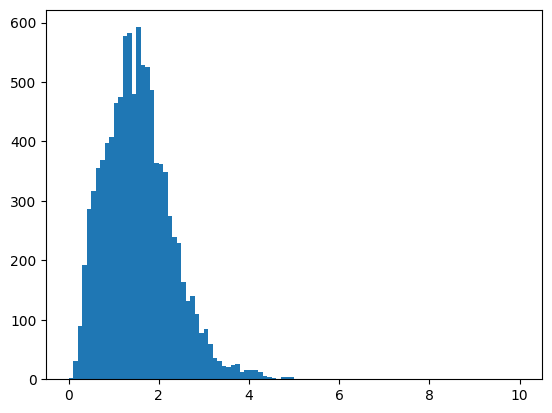

In [17]:
pdf = counts / np.sum(counts)
pdf_interp = interp1d(centers, pdf, kind='linear', bounds_error=False, fill_value=0)

samples = []
while len(samples) < 10000:
    z_try = np.random.uniform(0, 5)
    p = pdf_interp(z_try)
    if np.random.rand() < p / max(pdf):
        samples.append(z_try)

z_rej = np.array(samples)

plt.hist(z_rej, bins=edges)

## theorethical distribution

(0.0, 10.0)

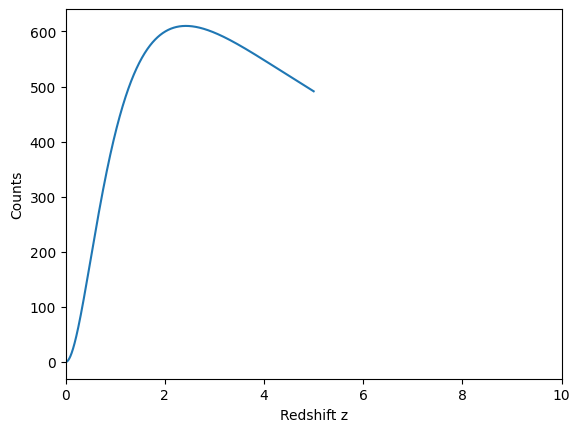

In [23]:
z_th = np.linspace(0.01, 5, 1000)
volume = cosmo.differential_comoving_volume(z_th).to(u.Mpc**3 / u.sr).value
volume = volume / np.max(volume)  

plt.plot(z_th, volume * np.max(counts))
plt.xlabel('Redshift z')
plt.ylabel('Counts')
plt.xlim(0,10)